# Train, one chunk of iterations at a time

`train.py` is a one-shot script: you run it, it trains for a fixed number of iterations, and you find out how it went only at the end. This notebook is the opposite — train a small batch of iterations, look at the loss and a sample, decide whether to keep going, change a setting, or stop. Same underlying training code as `train.py` (same `get_lr` schedule, same `get_batch` windowing, same `cross_entropy` + `AdamW` step), just broken into pieces you control.

**Two modes**, set in the config cell below:
- `MODE = "resume"` — keep training your existing checkpoint (`checkpoints/gpt_shakespeare.pt`), momentum and all
- `MODE = "fresh"` — start a brand-new model with whatever architecture you set (a different size can't reuse the old checkpoint's weights, since the shapes wouldn't match)

**Everything you can control**, all in the next cell: model size (`N_EMBD`, `N_HEAD`, `N_LAYER`, `BLOCK_SIZE`, `DROPOUT` — fresh mode only), the optimizer (`LEARNING_RATE`, `WEIGHT_DECAY`, `WARMUP_ITERS`), `BATCH_SIZE`, how long the cosine LR decay is shaped for (`SCHEDULE_HORIZON`), and how many iterations one call to `train_more()` runs before reporting back.

In [1]:
import math
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from model.gpt import GPT
from model.sample import sample
from tokenizer.bpe import BPETokenizer

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"device: {device}")

Matplotlib is building the font cache; this may take a moment.


device: mps


## Config — everything you can control

In [2]:
MODE = "resume"   # "resume" (keep training the existing checkpoint) or "fresh" (start a new model)

# --- architecture knobs (FRESH mode only -- resuming reuses the checkpoint's own config) ---
N_EMBD = 128
N_HEAD = 4
N_LAYER = 4
BLOCK_SIZE = 128
DROPOUT = 0.1

# --- optimizer / training knobs (apply in BOTH modes) ---
BATCH_SIZE = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_ITERS = 200
SCHEDULE_HORIZON = 8000   # total iters the cosine LR decay is shaped for -- set this to
                          # roughly how far you actually plan to train overall
MIN_LR = 3e-5

ITERS_PER_CALL = 200      # how many steps train_more() runs each time you call it

DATA_PATH = "data/tinyshakespeare.txt"
RESUME_CHECKPOINT = "checkpoints/gpt_shakespeare.pt"
SAVE_CHECKPOINT = "checkpoints/gpt_shakespeare.pt" if MODE == "resume" else "checkpoints/gpt_experiment.pt"

print(f"mode: {MODE}")
print(f"will save to: {SAVE_CHECKPOINT}")

mode: resume
will save to: checkpoints/gpt_shakespeare.pt


## Set up data, model, and optimizer

In [3]:
tok = BPETokenizer()
tok.load("tokenizer/vocab.json")

with open(DATA_PATH) as f:
    text = f.read()
ids = torch.tensor(tok.encode(text), dtype=torch.long)
n = int(0.9 * len(ids))
train_data, val_data = ids[:n], ids[n:]
print(f"corpus: {len(ids):,} tokens ({n:,} train / {len(ids)-n:,} val)")

corpus: 443,727 tokens (399,354 train / 44,373 val)


In [4]:
loss_history = []   # (iter, train_loss, val_loss) tuples, filled in as we go

if MODE == "resume":
    ckpt = torch.load(RESUME_CHECKPOINT, map_location=device)
    cfg = ckpt["config"]
    BLOCK_SIZE = cfg["block_size"]  # keep consistent with the loaded model
    model = GPT(**cfg).to(device)
    model.load_state_dict(ckpt["model"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    if "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
        print("resumed model AND optimizer state (momentum carries over cleanly)")
    else:
        print("checkpoint has no saved optimizer state (older format) -- "
              "model weights resumed, optimizer starts fresh")
    global_iter = ckpt["iter"]
else:
    cfg = dict(vocab_size=tok.vocab_size, n_embd=N_EMBD, n_head=N_HEAD,
               n_layer=N_LAYER, block_size=BLOCK_SIZE, dropout=DROPOUT)
    model = GPT(**cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    global_iter = 0
    print("started a brand-new model")

print(f"config: {cfg}")
print(f"params: {model.num_params():,}")
print(f"starting from iteration {global_iter}")

checkpoint has no saved optimizer state (older format) -- model weights resumed, optimizer starts fresh
config: {'vocab_size': 1024, 'n_embd': 128, 'n_head': 4, 'n_layer': 4, 'block_size': 128, 'dropout': 0.1}
params: 922,880
starting from iteration 6000


## Train more iterations — re-run this cell as many times as you like

Each call trains `ITERS_PER_CALL` more steps (from the config cell), reports the resulting loss, and keeps going from wherever it left off. Nothing resets between calls -- `global_iter`, the model weights, and the optimizer's momentum all persist for as long as this notebook's kernel stays running.

In [5]:
def get_lr(it):
    if it < WARMUP_ITERS:
        return LEARNING_RATE * (it + 1) / WARMUP_ITERS
    if it > SCHEDULE_HORIZON:
        return MIN_LR
    decay_ratio = (it - WARMUP_ITERS) / max(1, SCHEDULE_HORIZON - WARMUP_ITERS)
    coeff = 0.5 * (1 + math.cos(math.pi * decay_ratio))
    return MIN_LR + coeff * (LEARNING_RATE - MIN_LR)

def get_batch(data):
    ix = torch.randint(len(data) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([data[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + BLOCK_SIZE] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_val_loss(n_batches=20):
    model.eval()
    losses = []
    for _ in range(n_batches):
        x, y = get_batch(val_data)
        logits = model(x)
        losses.append(F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1)).item())
    model.train()
    return sum(losses) / len(losses)

def train_more(n_iters=None):
    global global_iter
    n_iters = n_iters or ITERS_PER_CALL
    t0 = time.time()
    train_losses = []
    for _ in range(n_iters):
        lr = get_lr(global_iter)
        for g in optimizer.param_groups:
            g["lr"] = lr
        x, y = get_batch(train_data)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        global_iter += 1

    avg_train = sum(train_losses) / len(train_losses)
    val_loss = estimate_val_loss()
    loss_history.append((global_iter, avg_train, val_loss))
    elapsed = time.time() - t0
    print(f"iter {global_iter:6d} | avg train loss {avg_train:.4f} | val loss {val_loss:.4f} | "
          f"lr {lr:.2e} | {elapsed:.1f}s for {n_iters} iters")

train_more()

iter   6200 | avg train loss 4.3588 | val loss 4.5052 | lr 6.40e-05 | 34.0s for 200 iters


**Re-run the cell above** (or select it and press `Shift+Enter` repeatedly) to keep training in `ITERS_PER_CALL`-sized chunks. Run the cells below anytime to check in without interrupting the training state.

## Check in: loss curve so far

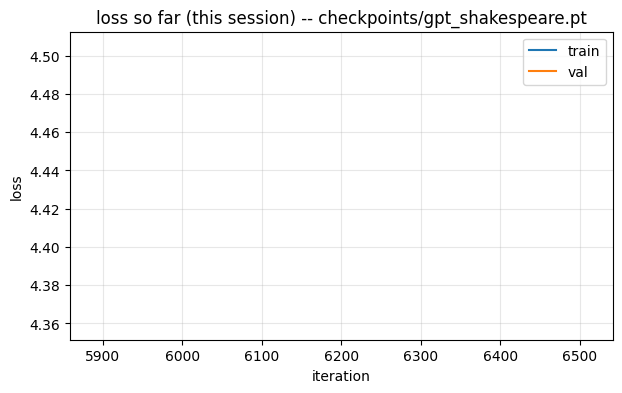

In [6]:
if loss_history:
    iters, trains, vals = zip(*loss_history)
    plt.figure(figsize=(7, 4))
    plt.plot(iters, trains, label="train")
    plt.plot(iters, vals, label="val")
    plt.xlabel("iteration")
    plt.ylabel("loss")
    plt.title(f"loss so far (this session) -- {SAVE_CHECKPOINT}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("no data yet -- run the train_more() cell above first")

## Check in: generate a sample at the current state

In [7]:
@torch.no_grad()
def generate(prompt, max_new_tokens=80, temperature=0.8, top_k=40):
    model.eval()
    out_ids = tok.encode(prompt)
    for _ in range(max_new_tokens):
        x = torch.tensor([out_ids[-model.block_size:]], device=device)
        logits = model(x)
        next_id = sample(logits[0, -1], temperature=temperature, top_k=top_k).item()
        out_ids.append(next_id)
    model.train()
    return tok.decode(out_ids)

print(f"[iter {global_iter}]")
print(generate("ROMEO:"))

[iter 6200]


ROMEO: mid me that tearing in his powers be bease.
Do and I were great and behus,
Yet the wort, min thy strong him, as a breat;
But let a bloody to the peewell it.

BEONTES:
Gentlehill honour, sir, but a will must 


## Save a checkpoint whenever you want

Unlike `train.py` (which only saves every `EVAL_INTERVAL` iterations automatically), here you decide when. Run this cell any time you're happy with where training is.

In [8]:
torch.save({
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "iter": global_iter,
    "config": cfg,
}, SAVE_CHECKPOINT)
print(f"saved iter {global_iter} to {SAVE_CHECKPOINT}")

saved iter 6200 to checkpoints/gpt_shakespeare.pt
